<a href="https://colab.research.google.com/github/alejitovm97-byte/Alejo-Varelas-projects/blob/gh-pages/04_investment_clock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INVESTMENT CLOCK v2 — reconstruccion con variables corregidas
# ============================================================
# Reemplaza a 03_investment_clock.py. El 03 queda como referencia de lo ya
# explorado, no se modifica.
#
# La especificacion de este notebook esta en desviaciones.md. Resumen de que
# cambia y por que:
#
#   D-10  Eje crecimiento: brecha del desempleo contra tendencia causal de 84
#         meses, sobre vintages de UNRATE. NO el output gap con vintages
#         actuales, que tenia look-ahead medido: la revision media era el 80%
#         del desvio de la propia señal y el 24.8% de los meses cambiaba de
#         fase. Con el eje causal el gate pasa 4/4; con el viejo, 2/4.
#   D-10  Eje inflacion: cpi_yoy.rolling(12).mean().diff(18).
#   D-09  ism_serv era en realidad ISM Manufacturero New Orders. Se renombra y
#         va SEPARADO (no promediado con el headline) a los predictores.
#   D-07  Holdout por fecha de calendario fija, nunca por porcentaje.
#   D-11  Trial log idempotente, con n_configs y con el Sharpe de CADA
#         configuracion, no solo del ganador.
# ============================================================


# ============================================================
# BLOQUE 0 — PASO 0.1 — Drive y estructura de carpetas
# ============================================================
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

ROOT_V1 = Path('/content/drive/MyDrive/TFM_regime_allocation')
ROOT    = ROOT_V1 / 'v2'          # subcarpeta propia: NO se pisan los datos del 03

DIRS = {
    'raw':       ROOT / 'data' / 'raw',
    'processed': ROOT / 'data' / 'processed',
    'config':    ROOT / 'config',
    'results':   ROOT / 'results',
    'figures':   ROOT / 'results' / 'figures',
    'logs':      ROOT / 'logs',
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print(f'ROOT v2: {ROOT}')
print(f'(datos del 03 intactos en {ROOT_V1})')


Mounted at /content/drive
ROOT v2: /content/drive/MyDrive/TFM_regime_allocation/v2
(datos del 03 intactos en /content/drive/MyDrive/TFM_regime_allocation)


In [ ]:
# ============================================================
# BLOQUE 0 — PASO 0.2 — Instalacion MINIMA
# ============================================================
# Por que cambia respecto del 03:
# El 0.2a del 03 hacia --force-reinstall de numpy 1.26.4 / pandas 2.1.4 y
# despues mataba el runtime. Colab hoy trae numpy 2.x, y forzar 1.26 rompe la
# compatibilidad binaria de todo lo precompilado contra numpy 2 — pyarrow
# incluido, que es lo que hace falta para leer parquet. De ahi venian los
# cuelgues al inicio de sesion.
#
# Regla nueva: SOLO se instala lo que falta, y SOLO cuando hace falta.
#   - Sesion de ANALISIS (leer parquets ya guardados): no instala nada.
#   - Sesion de DESCARGA: fredapi y/o refinitiv-data, sin fijar versiones.
# Si algun dia una version rompe algo, se fija ESA sola, con --no-deps, y se
# documenta el motivo aca.

# fredapi y pyyaml son Python puro: no tienen riesgo de compatibilidad binaria,
# asi que se instalan siempre que falten y listo. Lo que rompia el 03 era forzar
# numpy y pandas, no esto.
# MODO solo gobierna Refinitiv, que si es pesado y solo hace falta para el panel
# de retornos (que ya existe del 03).
MODO = 'analisis'        # 'analisis' | 'con_refinitiv'

import importlib.util, subprocess, sys

def asegurar(paquete, modulo=None):
    mod = modulo or paquete
    if importlib.util.find_spec(mod) is None:
        print(f'  instalando {paquete}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', paquete], check=True)
        # Sin esto, el interprete ya corriendo puede no ver el paquete recien
        # instalado: importlib cachea el arbol de modulos al arrancar.
        importlib.invalidate_caches()
        if importlib.util.find_spec(mod) is None:
            raise RuntimeError(f'{paquete} se instalo pero sigue sin verse. '
                               f'Reinicia el runtime UNA vez y volve a correr.')

asegurar('fredapi')
asegurar('pyyaml', 'yaml')
if MODO == 'con_refinitiv':
    asegurar('refinitiv-data', 'refinitiv')

import warnings, json, hashlib
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f'MODO={MODO}  |  numpy {np.__version__}  pandas {pd.__version__}')
try:
    import pyarrow
    print(f'pyarrow {pyarrow.__version__} — lectura de parquet OK')
except ImportError:
    print('AVISO: pyarrow no disponible, no se van a poder leer parquets')

  instalando fredapi...
MODO=analisis  |  numpy 2.1.3  pandas 2.2.3
pyarrow 23.0.1 — lectura de parquet OK


In [ ]:
# ============================================================
# BLOQUE 0 — PASO 0.3 — Secretos
# ============================================================
from google.colab import userdata

def get_secret(nombre, obligatorio=True):
    """Lee un secreto de Colab. Nunca imprime ni loguea el valor."""
    try:
        val = userdata.get(nombre)
        if not val:
            raise ValueError
        return val
    except Exception:
        if obligatorio:
            raise RuntimeError(f'Falta el secreto {nombre} en Colab')
        return None

FRED_KEY = get_secret('FRED_API_KEY')     # siempre: el reloj entero sale de FRED
print('Secretos: OK (valores nunca impresos)')

Secretos: OK (valores nunca impresos)


In [ ]:
# ============================================================
# BLOQUE 0 — PASO 0.4 — Config global y holdout
# ============================================================
# HOLDOUT POR FECHA FIJA, no por porcentaje (D-07).
# Con corte porcentual, extender la muestra hacia atras mueve el corte y
# convierte en "holdout" un tramo ya mirado como train. Contaminacion
# silenciosa y retroactiva.
#
# ADVERTENCIA HONESTA sobre el alcance del holdout en este proyecto:
# la especificacion del RELOJ (eje causal 84m, MA12/diff18, descarte de CFNAI)
# se eligio mirando estadisticos de MUESTRA COMPLETA — el gate, las frecuencias
# vs el paper, la persistencia. Eso es especificacion in-sample, y pretender que
# 2018-2026 sigue siendo holdout para el reloj seria ficcion.
# Por lo tanto: el reloj se declara IN-SAMPLE. El holdout protege las decisiones
# que TODAVIA NO SE TOMARON — construccion de factores, validacion de patrones y
# pesos de cartera (Fases 2 a 5), que es donde vive el riesgo real de overfitting.

CONFIG = {
    'muestra': {
        'inicio': '1991-01-31',
        'fin':    '2026-07-31',
    },
    # Hay DOS holdouts, con estados distintos.
    'holdout_inversion': {
        'desde': '2018-01-01',
        'estado': 'LIMPIO',
        'protege': 'Fases 2-5: factores, validacion de patrones, pesos de cartera',
        'por_que_limpio': 'no se construyo ningun factor ni se tomo ninguna decision '
                          'de cartera todavia. Es el holdout que importa: de ahi '
                          'salen las decisiones de inversion.',
    },
    'holdout_reloj': {
        'estado': 'QUEMADO',
        'por_que': 'la especificacion (ventana 84m, MA12/diff18, descarte de CFNAI) '
                   'se eligio mirando gate, frecuencias y persistencia sobre los 427 '
                   'meses completos. Lo quemo la SELECCION, no que los datos lleguen '
                   'a 2026: especificar con 1991-2017 y aplicar a 2018-2026 sin mirar '
                   'habria sido valido.',
        'reemplazo': 'forward out-of-sample desde la fecha de congelamiento',
    },
    # Forward out-of-sample: lo unico verdaderamente limpio que queda para el reloj.
    # Datos que aun no existen no pueden haber influido en ninguna decision.
    # CONDICION 1: no tocar la especificacion. Si se retoca, tambien se quema.
    # CONDICION 2: se acumula lento. Con fases de ~15.3 meses, un anio de datos
    #              nuevos da menos de un episodio independiente. Es validacion
    #              continua, no algo reportable a corto plazo.
    'congelamiento': {
        'fecha': '2026-09-02',
        'datos_hasta': '2026-07-31',
        'especificacion_congelada': {
            'crecimiento': 'compuesto 50/50: 0.5*escala(brecha_nivel_UNRATE) + '
                           '0.5*promedio(escala(brecha_tasa) de PAYEMS, INDPRO, PCEC96), '
                           'ventana 84m, todo sobre vintages ALFRED',
            'inflacion':   'cpi_yoy.rolling(12).mean().diff(18)  [CPIAUCNS, vintages]',
            'clasificacion': 'signo de ambos ejes con banda muerta 0.10 e histeresis',
        },
        'regla': 'todo mes posterior a 2026-07-31 es out-of-sample genuino del reloj '
                 'MIENTRAS la especificacion de arriba no se modifique.',
    },
    'eje_crecimiento': {
        'tipo': 'compuesto coincidente 50/50',
        'fuente': 'FRED/ALFRED con vintages',
        'ventana_tendencia_meses': 84,
        'componentes': {
            'UNRATE':  'brecha de NIVEL: -(x_t - media_movil_84(x))  [holgura laboral]',
            'PAYEMS':  'brecha de TASA: yoy_t - media_movil_84(yoy)  [demanda de trabajo]',
            'INDPRO':  'brecha de TASA                                [produccion]',
            'PCEC96':  'brecha de TASA                                [consumo real]',
        },
        'ponderacion': '50% UNRATE + 50% promedio(PAYEMS, INDPRO, PCEC96)',
        'por_que_5050': 'UNRATE es brecha de nivel y las otras tres de tasa. Entre si '
            'las tres de tasa correlacionan 0.68-0.78, mientras UNRATE correlaciona '
            '0.28-0.57 con ellas. Equiponderar las cuatro le daria 3/4 del peso al '
            'bloque de tasas (desvio vs paper 33.9pp). El 50/50 balancea nivel contra '
            'tasa en vez de contar series.',
        'escalado': 'division por IQR expansivo, SIN restar la mediana: el cero de '
            'cada brecha ya significa "en su propia norma" y hay que preservarlo '
            '(ver trial_log 3.3-3.4 del 03: normalizar destruye el cero).',
        'descartadas': {
            'DSPIC96': 'ingreso disponible INCLUYE transferencias. En mayo-2020 marco '
                       '+10.84 (la lectura mas positiva de la muestra) mientras PCEC96 '
                       'estaba en -19.80 e INDPRO en -16.03: los cheques del CARES Act. '
                       'Correlaciona NEGATIVO con todos los demas (-0.13 a -0.32). Es '
                       'anticiclica, no coincidente.',
            'W875RX1': 'seria la correcta (ingreso menos transferencias) pero ALFRED '
                       'solo tiene vintages desde 2010.',
            'CMRMTSPL': 'vintages solo desde 2013.',
            'CFNAI':   'vintages solo desde 2015 (ver D-10).',
            'TCU':     'vintages solo desde 1996.',
        },
    },
    # DOS ejes de inflacion, con roles distintos. No son candidatos rivales:
    # miden cosas distintas y las dos hacen falta.
    'eje_inflacion': {
        'rol': 'CLASIFICADOR DE REGIMEN — define las fases historicas (Fases 3-4)',
        'serie': 'cpi_yoy (CPIAUCNS, vintages)',
        'formula': 'rolling(12).mean().diff(18)',
        'retraso': '13 meses (corr 0.508 con el cambio contemporaneo del cpi_yoy)',
        'por_que_este': 'los activos cotizan REGIMENES inflacionarios persistentes, no '
            'los vaivenes mes a mes. Con este eje la dispersion de retornos entre '
            'fases es 13.0% y el desvio vs paper 10.8pp; con el rapido caen a ~9% y '
            'suben a 18-27pp. Un eje mas responsivo produce fases que separan PEOR '
            'los retornos, que es justo lo que la Fase 3 necesita que separen bien.',
    },
    'eje_inflacion_rapido': {
        'rol': 'ESTADO ACTUAL — donde estamos hoy, para el tilt y la regla de '
               'confirmacion del Bloque 5',
        'serie': 'cpi_yoy (CPIAUCNS, vintages)',
        'formula': 'yoy - rolling(12).mean()   [definicion literal de Merrill]',
        'retraso': '1 mes (corr 0.786) — practicamente contemporaneo, y ademas el que '
                   'mejor sigue el ciclo de inflacion de las cuatro especificaciones '
                   'probadas (merrill, MA24, diff12, diff18)',
        'como_usarlo': 'NO reemplaza al clasificador. Se reporta al lado. Cuando los '
            'dos discrepan, esa discrepancia ES la senal de que hay una transicion en '
            'curso: el lento describe el regimen vigente, el rapido el estado de hoy.',
    },
    'clasificacion': {
        'banda_muerta': 0.10,
        'regla': 'la fase cambia solo si el eje supera la banda; dentro de la banda '
                 'se mantiene el estado anterior (histeresis)',
        'por_que': 'un clasificador por signo aplicado a una variable que orbita el '
                   'cero cambia de fase sin que pase nada economicamente. La banda '
                   'sube la persistencia de 15.2 a 18.6 meses Y mejora el ajuste al '
                   'paper de 15.8 a 14.8 pp: gana en las dos, no es trade-off.',
    },
    'limitaciones_declaradas': {
        'covid_en_la_tendencia': 'la ventana de 84 meses contiene 5 meses con '
            'desempleo >8% (2020). Eso infla la tendencia ~0.43 pp y por lo tanto '
            'infla el eje crecimiento en la misma magnitud, hasta que COVID salga '
            'de la ventana a mediados de 2027. Las lecturas de fase de 2020-2027 '
            'tienen SESGO CONOCIDO Y HACIA ARRIBA. Se probaron mediana, media '
            'recortada y exclusion explicita de los meses COVID: las tres empeoran '
            'persistencia y ajuste (la exclusion hunde la persistencia de 2020-2026 '
            'a 8.8 meses). Se declara el sesgo en vez de corregirlo mal.',
        'retraso_del_eje_inflacion': 'el eje detecta los giros de inflacion con ~13 '
            'meses de retraso (correlacion 0.508 con el cambio contemporaneo del CPI '
            'interanual). diff12 seria algo mejor (11 meses, corr 0.674) pero pierde '
            'persistencia. Es inherente a la familia MA12(...).diff(d): el promedio '
            'de 12 meses solo ya cuesta ~6 meses. Anticipar el giro es tarea del '
            'Bloque 5, no del eje coincidente.',
    },
    'costos': {
        'nota': 'definir antes del backtest; nunca reportar Sharpe bruto',
    },
}

path_config = DIRS['config'] / 'config_v2.json'
path_config.write_text(json.dumps(CONFIG, indent=2, ensure_ascii=False))
print(f'Config guardada en {path_config.name}')
print(f"MUESTRA          : {CONFIG['muestra']['inicio']} -> {CONFIG['muestra']['fin']}")
print(f"HOLDOUT inversion: desde {CONFIG['holdout_inversion']['desde']} "
      f"[{CONFIG['holdout_inversion']['estado']}] — NO MIRAR para Fases 2-5")
print(f"HOLDOUT reloj    : {CONFIG['holdout_reloj']['estado']} "
      f"-> reemplazado por forward OOS")
print(f"CONGELADO        : {CONFIG['congelamiento']['fecha']}, datos hasta "
      f"{CONFIG['congelamiento']['datos_hasta']}")

Config guardada en config_v2.json
MUESTRA          : 1991-01-31 -> 2026-07-31
HOLDOUT inversion: desde 2018-01-01 [LIMPIO] — NO MIRAR para Fases 2-5
HOLDOUT reloj    : QUEMADO -> reemplazado por forward OOS
CONGELADO        : 2026-09-02, datos hasta 2026-07-31


In [ ]:
# ============================================================
# BLOQUE 0 — PASO 0.5 — Trial log v2
# ============================================================
# Tres arreglos respecto del log del 03 (ver D-11):
#
# 1) IDEMPOTENTE. El log del 03 appendeaba en cada re-ejecucion: 64 filas eran
#    ~13 eventos unicos. Aca la clave (bloque, paso, parametros) se deduplica.
#
# 2) n_configs EXPLICITO. En el 03 la cantidad de configuraciones probadas
#    quedaba enterrada en prosa ("6 candidatos x 4 esquemas"), asi que el total
#    no era sumable y el DSR uso 23 cuando el espacio explorado eran ~89.
#
# 3) SHARPE DE CADA CONFIGURACION, no solo del ganador. Este es el arreglo que
#    de verdad importa. Var[SR] necesita la DISPERSION de los Sharpe probados;
#    si solo se guarda el del ganador, hay que estimarla sobre las variantes
#    finales, que comparten estructura y periodo y la subestiman. Es exactamente
#    lo que paso en el PASO 5.6 del 03 y esta anotado en el propio log.

PATH_TRIALS = DIRS['logs'] / 'trial_log_v2.csv'

# Piso historico: las ~89 configuraciones ya exploradas en el 03 y en la sesion
# de diagnostico. N NO SE RESETEA con el notebook nuevo: las decisiones de
# especificacion de aca (eje causal 84m, MA12/diff18, descarte de CFNAI) estan
# informadas por todo eso. No se puede des-ver.
TRIALS_HISTORICOS = 89

COLS_TRIAL = ['timestamp','bloque','paso','descripcion','parametros','n_configs',
              'sharpes_json','sharpe_ganador','n_obs','skew','kurtosis','notas']

def _clave(bloque, paso, parametros):
    return hashlib.md5(f'{bloque}|{paso}|{parametros}'.encode()).hexdigest()[:12]

def log_trial(bloque, paso, descripcion, parametros, n_configs,
              sharpes=None, sharpe_ganador=None, n_obs=None,
              skew=None, kurtosis=None, notas=None):
    """Registra un evento de busqueda. Idempotente sobre (bloque, paso, parametros).

    sharpes: lista con el Sharpe de TODAS las configuraciones probadas en este
             evento. Es lo que alimenta Var[SR] en el DSR. Pasarlo siempre que
             las configuraciones tengan un Sharpe medible.
    """
    if PATH_TRIALS.exists():
        tl = pd.read_csv(PATH_TRIALS)
    else:
        tl = pd.DataFrame(columns=COLS_TRIAL + ['clave'])

    k = _clave(bloque, paso, parametros)
    fila = {
        'timestamp': pd.Timestamp.now().isoformat(timespec='seconds'),
        'bloque': bloque, 'paso': paso, 'descripcion': descripcion,
        'parametros': parametros, 'n_configs': int(n_configs),
        'sharpes_json': json.dumps([round(float(s), 4) for s in sharpes]) if sharpes is not None else None,
        'sharpe_ganador': sharpe_ganador, 'n_obs': n_obs,
        'skew': skew, 'kurtosis': kurtosis, 'notas': notas, 'clave': k,
    }
    tl = tl[tl['clave'] != k]                      # deduplica: la ultima gana
    tl = pd.concat([tl, pd.DataFrame([fila])], ignore_index=True)
    tl.to_csv(PATH_TRIALS, index=False)
    print(f'  [trial] {bloque}/{paso}: {descripcion} ({n_configs} configs)')

def conteo_trials(verbose=True):
    """N total para el DSR: piso historico + lo registrado en este notebook."""
    n_nuevo = 0
    sharpes = []
    if PATH_TRIALS.exists():
        tl = pd.read_csv(PATH_TRIALS)
        n_nuevo = int(tl['n_configs'].fillna(0).sum())
        for s in tl['sharpes_json'].dropna():
            sharpes.extend(json.loads(s))
    total = TRIALS_HISTORICOS + n_nuevo
    if verbose:
        print(f'  historicos (03 + diagnostico) : {TRIALS_HISTORICOS}')
        print(f'  registrados en v2             : {n_nuevo}')
        print(f'  N PARA EL DSR                 : {total}')
        print(f'  Sharpes disponibles para Var[SR]: {len(sharpes)}')
        if len(sharpes) < 10:
            print('  AVISO: pocos Sharpe registrados. Var[SR] va a ser poco confiable.')
    return total, sharpes

print(f'Trial log: {PATH_TRIALS.name}')
conteo_trials()

Trial log: trial_log_v2.csv
  historicos (03 + diagnostico) : 89
  registrados en v2             : 21
  N PARA EL DSR                 : 110
  Sharpes disponibles para Var[SR]: 7
  AVISO: pocos Sharpe registrados. Var[SR] va a ser poco confiable.


(110, [0.3471, 0.5166, 0.2868, 0.4615, 0.2978, 0.0956, 0.5221])

In [ ]:
# ============================================================
# BLOQUE 0 — PASO 0.6 — Conexiones PEREZOSAS
# ============================================================
# No se conecta nada al importar. Las funciones se llaman solo cuando hay que
# descargar. Asi una sesion de analisis no toca Refinitiv ni FRED, que es de
# donde venia el "siempre cuesta conectarse al inicio de la sesion".

_fred = None
def fred_api():
    """Devuelve el cliente de FRED, conectando la primera vez que se pide."""
    global _fred
    if _fred is None:
        from fredapi import Fred
        _fred = Fred(api_key=FRED_KEY)
        v = _fred.get_series('VIXCLS', observation_start='2024-01-01').dropna()
        print(f'FRED conectado (VIX al {v.index[-1].date()} = {v.iloc[-1]})')
    return _fred

def abrir_refinitiv():
    """Abre sesion de plataforma RDP (password grant).
    Cierra cualquier sesion previa: re-correr con una sesion colgada falla.
    Misma logica que el 0.2c.2 del 03, pero perezosa."""
    import refinitiv.data as rd
    from refinitiv.data import session
    try:
        rd.close_session()
    except Exception:
        pass
    ses = session.platform.Definition(
        app_key=get_secret('REFINITIV_APP_KEY'),
        grant=session.platform.GrantPassword(
            username=get_secret('REFINITIV_USERNAME'),
            password=get_secret('REFINITIV_PASSWORD'),
        ),
    ).get_session()
    session.set_default(ses)
    ses.open()
    print(f'RDP: sesion abierta — estado {ses.open_state}')
    return rd

print('Conexiones perezosas listas: fred_api() y abrir_refinitiv()')
print('\nBLOQUE 0 COMPLETO.')

Conexiones perezosas listas: fred_api() y abrir_refinitiv()

BLOQUE 0 COMPLETO.


In [ ]:
# ============================================================
# BLOQUE 1 — PASO 1.0 — Utilidades de descarga con vintages
# ============================================================
# HALLAZGO QUE SIMPLIFICA TODO: los dos ejes del reloj salen ENTERAMENTE de FRED.
#   crecimiento -> UNRATE
#   inflacion   -> CPIAUCNS
# Refinitiv solo hace falta para el panel de retornos, y ese panel ya existe del
# 03 y no lo afecta ninguna de las correcciones (son precios de mercado, no
# macro revisable). O sea: EL RELOJ SE RECONSTRUYE SIN TOCAR REFINITIV.
#
# Por que CPIAUCNS (sin ajuste estacional) y no CPIAUCSL:
# la variacion interanual ya elimina la estacionalidad por construccion, asi que
# el ajuste estacional no aporta nada — y en cambio ES lo unico que se revisa del
# CPI (los factores estacionales se recalculan cada anio). Usando la serie NSA el
# eje inflacion queda inmune a revisiones por diseno, no por suerte.
#
# Sobre las vintages: ALFRED guarda una fila por (fecha_referencia, vintage) solo
# cuando el valor CAMBIA respecto de la vintage anterior. Por eso UNRATE tiene
# ~2.200 filas y no ~900 x cientos de vintages. vista() reconstruye lo que se
# veia en una fecha tomando, por cada fecha de referencia, la ultima revision
# publicada hasta ahi.
#
# Y una propiedad importante: usar realtime_start <= t SUBSUME el lag de
# publicacion. No hace falta tabla de lags como en el 1.4 del 03: si el dato de
# enero se publico en febrero, simplemente no aparece en la vista de enero.

def descargar_releases(sid, forzar=False):
    """Baja el historial completo de vintages de una serie de FRED y lo cachea.
    Con el cache en disco, re-correr no vuelve a pegarle a la API."""
    p = DIRS['raw'] / f'b1_releases_{sid}.parquet'
    if p.exists() and not forzar:
        r = pd.read_parquet(p)
        print(f'  {sid:12s} cache      {len(r):>7,} filas  '
              f'vintages {r["realtime_start"].min().date()} -> '
              f'{r["realtime_start"].max().date()}')
        return r
    try:
        r = fred_api().get_series_all_releases(sid)
    except ModuleNotFoundError as e:
        raise RuntimeError(
            f'Falta una libreria y no hay cache en {p}.\n'
            f'  Causa: {e}\n'
            f'  Arreglo: correr `!pip install -q fredapi` (o re-ejecutar el PASO 0.2, '
            f'que lo instala solo). No hace falta reiniciar el runtime.') from e
    except Exception as e:
        raise RuntimeError(
            f'No se pudo descargar {sid} y no hay cache en {p}.\n'
            f'  Causa: {type(e).__name__}: {e}\n'
            f'  Si es error de autenticacion, revisa el secreto FRED_API_KEY en Colab.') from e
    r['realtime_start'] = pd.to_datetime(r['realtime_start'])
    r['date']           = pd.to_datetime(r['date'])
    r = r.sort_values('realtime_start').reset_index(drop=True)
    r.to_parquet(p)
    print(f'  {sid:12s} descargado {len(r):>7,} filas  '
          f'vintages {r["realtime_start"].min().date()} -> '
          f'{r["realtime_start"].max().date()}')
    return r

def vista(rel, t):
    """Lo que se veia de la serie en la fecha t.
    Por cada fecha de referencia, la ultima revision publicada hasta t."""
    sub = rel[rel['realtime_start'] <= t]
    return sub.groupby('date')['value'].last()


# ============================================================
# BLOQUE 1 — PASO 1.1 — Series del reloj (solo FRED)
# ============================================================
print('Descarga de vintages:')
rel_unrate = descargar_releases('UNRATE')
rel_cpi    = descargar_releases('CPIAUCNS')

# Coincidentes del NBER que sobrevivieron el sondeo de vintages.
# El criterio fue: tener historia suficiente VISIBLE en 1991 (84 meses de
# tendencia + 12 de interanual). Los que no lo cumplen NO se reemplazan por la
# serie revisada de hoy: eso seria reintroducir el look-ahead que sacamos.
COINCIDENTES = ['PAYEMS', 'INDPRO', 'PCEC96']
rels = {sid: descargar_releases(sid) for sid in COINCIDENTES}


Descarga de vintages:
  UNRATE       cache        2,197 filas  vintages 1960-03-15 -> 2026-08-07
  CPIAUCNS     cache        2,524 filas  vintages 1949-03-24 -> 2026-08-12
  PAYEMS       cache       13,685 filas  vintages 1955-05-06 -> 2026-08-07
  INDPRO       cache       39,356 filas  vintages 1927-01-26 -> 2026-08-18
  PCEC96       cache        8,520 filas  vintages 1979-11-19 -> 2026-08-26


In [ ]:
# ============================================================
# BLOQUE 1 — PASO 1.2 — Panel de retornos (se importa del 03)
# ============================================================
# No se vuelve a descargar: son precios de mercado, no los toca ninguna de las
# correcciones de D-09 ni D-10. Se copia a v2 para que este notebook sea
# autocontenido de aca en adelante.
#
# PENDIENTE HEREDADO, anotarlo y no olvidarlo: la serie 'bonos' es un retorno
# total SINTETICO construido desde yields con aproximacion de duracion (pasos
# 0.7, 0.8 y 0.8b del 03). Se descarto como causa del mapeo anomalo — un sesgo de
# duracion desplaza el nivel de forma pareja y no puede invertir el orden entre
# fases — pero conviene auditarla antes del backtest final.

p_ret_v1 = ROOT_V1 / 'data' / 'processed' / 'b1_panel_retornos.parquet'
p_ret_v2 = DIRS['processed'] / 'b1_panel_retornos.parquet'

ret = pd.read_parquet(p_ret_v1)

# CAST A float64 DE NUMPY, en el origen.
# El panel del 03 viene con dtypes nullable de pandas (Float64, con pd.NA).
# np.sign, scipy.stats.f_oneway y varias operaciones se comportan mal con eso;
# por eso el 03 tenia un paso "4.1b — Cast a float" parcheandolo aguas abajo.
# Se arregla aca y no se vuelve a tocar.
antes = ret.dtypes.astype(str).unique().tolist()
ret = ret.astype('float64')
ret.index = pd.to_datetime(ret.index)
print(f'\nPanel de retornos importado del 03: dtypes {antes} -> float64')

ret.to_parquet(p_ret_v2)
print(f'  {ret.shape[0]} meses x {ret.shape[1]} activos {ret.columns.tolist()}')
print(f'  rango {ret.index.min().date()} -> {ret.index.max().date()}')
print(f'  primer mes completo: {ret.dropna().index.min().date()} '
      f'(1991-01 viene vacio: es el mes base del calculo de retornos)')



Panel de retornos importado del 03: dtypes ['Float64'] -> float64
  427 meses x 4 activos ['equity', 'commods', 'bonos', 'cash']
  rango 1991-01-31 -> 2026-07-31
  primer mes completo: 1991-02-28 (1991-01 viene vacio: es el mes base del calculo de retornos)


In [ ]:
# ============================================================
# BLOQUE 1 — PASO 1.3 — Auditoria de cobertura [GATE]
# ============================================================
INICIO = pd.Timestamp(CONFIG['muestra']['inicio'])
FIN    = pd.Timestamp(CONFIG['muestra']['fin'])
VENT   = CONFIG['eje_crecimiento']['ventana_tendencia_meses']

print('\n--- cobertura ---')
aud = []
for nombre, rel in [('UNRATE', rel_unrate), ('CPIAUCNS', rel_cpi)]:
    obs = rel.groupby('date')['value'].last()
    aud.append(dict(serie=nombre, tipo='vintages',
                    primera_obs=obs.index.min().date(),
                    ultima_obs=obs.index.max().date(),
                    n_obs=len(obs),
                    primera_vintage=rel['realtime_start'].min().date()))
for c in ret.columns:
    s = ret[c].dropna()
    aud.append(dict(serie=c, tipo='retorno',
                    primera_obs=s.index.min().date(),
                    ultima_obs=s.index.max().date(),
                    n_obs=len(s), primera_vintage=None))
aud = pd.DataFrame(aud)
print(aud.to_string(index=False))
aud.to_csv(DIRS['results'] / 'b1_auditoria_cobertura.csv', index=False)

# El eje crecimiento necesita VENT meses de historia disponible EN LA VINTAGE de
# cada fecha, no en la serie de hoy. Se verifica en la primera fecha de muestra.
u_ini = vista(rel_unrate, INICIO)
u_ini = u_ini[u_ini.index <= INICIO]
print(f'\nEn {INICIO.date()} se veian {len(u_ini)} meses de UNRATE '
      f'(hacen falta {VENT}) -> {"OK" if len(u_ini) >= VENT else "INSUFICIENTE"}')

# Control anti look-ahead: ninguna vista puede contener datos posteriores a su fecha.
fallas = 0
for t in pd.date_range(INICIO, FIN, freq='ME')[::24]:
    for rel in (rel_unrate, rel_cpi):
        v = vista(rel, t)
        if len(v) and v.index.max() > t:
            fallas += 1
print(f'Control anti look-ahead: {"OK" if fallas == 0 else f"{fallas} FALLAS"} '
      f'(ninguna vista contiene datos posteriores a su fecha)')


--- cobertura ---
   serie     tipo primera_obs ultima_obs  n_obs primera_vintage
  UNRATE vintages  1948-01-01 2026-07-01    943      1960-03-15
CPIAUCNS vintages  1913-01-01 2026-07-01   1363      1949-03-24
  equity  retorno  1991-02-28 2026-07-31    426            None
 commods  retorno  1991-02-28 2026-07-31    426            None
   bonos  retorno  1991-02-28 2026-07-31    426            None
    cash  retorno  1991-02-28 2026-07-31    418            None

En 1991-01-31 se veian 516 meses de UNRATE (hacen falta 84) -> OK
Control anti look-ahead: OK (ninguna vista contiene datos posteriores a su fecha)


In [ ]:
# ============================================================
# BLOQUE 1 — PASO 1.4 — Consistencia con el 03
# ============================================================
# El 03 tomaba el CPI de Refinitiv (USCPI=ECI); aca sale de FRED (CPIAUCNS).
# Antes de darlo por bueno hay que confirmar que son la misma inflacion: si
# divergen, el eje inflacion no es comparable con nada de lo ya validado.

cpi_hoy = vista(rel_cpi, pd.Timestamp.today())
cpi_yoy_v2 = (cpi_hoy.pct_change(12) * 100).rename('cpi_yoy_v2')
cpi_yoy_v2.index = cpi_yoy_v2.index + pd.offsets.MonthEnd(0)

dm_v1 = pd.read_parquet(ROOT_V1 / 'data' / 'processed' / 'b1_datos_mensuales.parquet')

# Las dos series estan indexadas distinto: la del 03 ya trae aplicado el lag de
# publicacion del PASO 1.4; esta va por mes de referencia. Compararlas sin mas
# mide el desfase, no las fuentes. Se barre el shift y se busca el pico.
print('\n--- CPI: FRED (CPIAUCNS) vs Refinitiv (USCPI=ECI), por desfase ---')
mejor = (None, -1)
for s in [-2, -1, 0, 1, 2]:
    c = pd.concat([dm_v1['cpi_yoy'], cpi_yoy_v2.shift(s)], axis=1).dropna()
    r = c.corr().iloc[0, 1]
    dif = (c.iloc[:, 0] - c.iloc[:, 1]).abs().mean()
    print(f'  shift {s:>+2}: corr {r:.5f}   dif media {dif:.3f} pp')
    if r > mejor[1]:
        mejor = (s, r, dif)
print(f'  -> pico en shift {mejor[0]:+d} (corr {mejor[1]:.5f}, dif {mejor[2]:.3f} pp)')
print('  Un pico NITIDO con corr >0.999 significa que las dos fuentes son la misma')
print('  inflacion y solo cambiaba el indexado. Si el maximo es chato o <0.99,')
print('  las series difieren de verdad: PARAR e investigar antes de seguir.')

log_trial(1, '1.1-1.4', 'Fuentes del reloj v2', n_configs=1,
          parametros='UNRATE + CPIAUCNS de ALFRED con vintages; retornos importados del 03',
          notas='Los dos ejes salen solo de FRED: el reloj se reconstruye sin Refinitiv. '
                'CPIAUCNS (NSA) elegido porque la variacion interanual ya quita la '
                'estacionalidad y el ajuste estacional es lo unico revisable del CPI. '
                'realtime_start <= t subsume el lag de publicacion, no hace falta tabla de lags.')

print('\nBLOQUE 1 COMPLETO.')


--- CPI: FRED (CPIAUCNS) vs Refinitiv (USCPI=ECI), por desfase ---
  shift -2: corr 0.84129   dif media 0.575 pp
  shift -1: corr 0.90361   dif media 0.461 pp
  shift +0: corr 0.96567   dif media 0.283 pp
  shift +1: corr 0.99916   dif media 0.047 pp
  shift +2: corr 0.96592   dif media 0.283 pp
  -> pico en shift +1 (corr 0.99916, dif 0.047 pp)
  Un pico NITIDO con corr >0.999 significa que las dos fuentes son la misma
  inflacion y solo cambiaba el indexado. Si el maximo es chato o <0.99,
  las series difieren de verdad: PARAR e investigar antes de seguir.
  [trial] 1/1.1-1.4: Fuentes del reloj v2 (1 configs)

BLOQUE 1 COMPLETO.


In [ ]:
# ============================================================
# BLOQUE 2 — PASO 2.1 — Eje CRECIMIENTO (causal, real-time)
# ============================================================
# crecimiento(t) = -(UNRATE_t - media_movil_84(UNRATE hasta t))
#
# Signo invertido a proposito: desempleo POR DEBAJO de su tendencia = economia
# por encima del potencial = crecimiento positivo.
#
# Todo se calcula sobre la VISTA de cada fecha, no sobre la serie de hoy:
#   - la media movil usa solo meses ya publicados a t
#   - el valor de UNRATE es el de la vintage vigente en t, no el revisado
# Por eso no hay ningun parametro de lag: realtime_start <= t lo resuelve.
#
# El rezago de la media movil NO es un defecto (ver D-10). Un observador en 2015
# no sabia que el desempleo iba a seguir cayendo hasta 3.5%. El rezago ES lo que
# era conocible en el momento.

VENT    = CONFIG['eje_crecimiento']['ventana_tendencia_meses']
MIN_OBS = 60
# CALENTAMIENTO: el escalado causal necesita MIN_OBS meses de historia de la propia
# brecha antes de dar un valor. Si empezaramos a calcular en 1991, el eje arrancaria
# en 1996 y perderiamos los 5 primeros anios de muestra. Calculando desde 1981 el
# escalado llega ya estimado a 1991. Sigue siendo causal: en cada fecha se usa solo
# historia previa. El limite es PCEC96, con vintages desde 1979-11.
BURN_IN = pd.Timestamp('1981-01-31')

def brecha(rel, modo):
    """Brecha causal, calculada sobre la VISTA de cada fecha (no la serie de hoy).
    modo='nivel': -(x_t - media_movil_VENT(x))    -> holgura, para UNRATE
    modo='tasa' :  yoy_t - media_movil_VENT(yoy)  -> para las series con tendencia,
                   donde 'nivel vs media movil' no aplica porque crecen."""
    f = []
    for t in pd.date_range(BURN_IN, FIN, freq='ME'):
        u = vista(rel, t); u = u[u.index <= t]
        if modo == 'nivel':
            if len(u) < VENT: continue
            g = -(u.iloc[-1] - u.iloc[-VENT:].mean())
        else:
            y = (u.pct_change(12) * 100).dropna()
            if len(y) < VENT: continue
            g = y.iloc[-1] - y.iloc[-VENT:].mean()
        f.append({'t': t, 'mes_ref': u.index[-1], 'g': g})
    return pd.DataFrame(f).set_index('t')

def escala_causal(s, min_obs=MIN_OBS):
    """Iguala escalas dividiendo por el IQR expansivo, SIN restar la mediana.
    Restarla correria el cero, que en cada brecha significa 'en su propia norma'.
    Es el error que el trial_log 3.3-3.4 del 03 ya habia identificado."""
    iqr = (s.expanding(min_obs).quantile(0.75) -
           s.expanding(min_obs).quantile(0.25))
    return s / iqr.replace(0, np.nan)

COMPONENTES = [('UNRATE', 'nivel'), ('PAYEMS', 'tasa'),
               ('INDPRO', 'tasa'),  ('PCEC96', 'tasa')]
brechas, mes_ref = {}, None
for sid, modo in COMPONENTES:
    b = brecha(rel_unrate if sid == 'UNRATE' else rels[sid], modo)
    brechas[sid] = b['g']
    if sid == 'UNRATE':
        mes_ref = b['mes_ref']
    print(f'  {sid:8s} {modo:6s} {len(b):>4} meses desde {b.index.min().date()}')

B = pd.DataFrame(brechas)
Z = B.apply(escala_causal)
eje_c = 0.5 * Z['UNRATE'] + 0.5 * Z[['PAYEMS', 'INDPRO', 'PCEC96']].mean(axis=1)

crec = pd.DataFrame({'crecimiento': eje_c, 'mes_ref': mes_ref})
crec = crec.dropna(subset=['crecimiento']).loc[INICIO:]   # se descarta el calentamiento

print(f'\n--- correlacion entre las brechas ---')
C = B.corr()
print(C.round(2).to_string())
tasas = ['PAYEMS', 'INDPRO', 'PCEC96']
c_un = C.loc['UNRATE', tasas]
c_ta = C.loc[tasas, tasas].where(~np.eye(3, dtype=bool)).stack()
print(f'  UNRATE vs el bloque de tasas: {c_un.min():.2f} a {c_un.max():.2f}')
print(f'  bloque de tasas entre si   : {c_ta.min():.2f} a {c_ta.max():.2f}')
print(f'  Por eso 50/50 y no equiponderado: la diversificacion viene de la '
      f'construccion (nivel vs tasa), no de la cantidad de series.')

sg = np.sign(crec['crecimiento']); e = (sg != sg.shift()).cumsum()
print(f'\nEje CRECIMIENTO (compuesto): {len(crec)} meses '
      f'({crec.index.min().date()} -> {crec.index.max().date()})')
print(f'  calentamiento descartado: {BURN_IN.date()} -> {INICIO.date()}')
print(f'  rango {crec.crecimiento.min():+.2f} a {crec.crecimiento.max():+.2f}')
print(f'  persistencia del signo: {sg.groupby(e).size().mean():.1f} meses')
print(f'  rezago del dato: mes de referencia {crec.mes_ref.iloc[-1].date()} '
      f'para la fila {crec.index[-1].date()}')

B.to_parquet(DIRS['processed'] / 'b2_brechas_componentes.parquet')


  UNRATE   nivel   547 meses desde 1981-01-31
  PAYEMS   tasa    547 meses desde 1981-01-31
  INDPRO   tasa    547 meses desde 1981-01-31
  PCEC96   tasa    547 meses desde 1981-01-31

--- correlacion entre las brechas ---
        UNRATE  PAYEMS  INDPRO  PCEC96
UNRATE    1.00    0.60    0.28    0.36
PAYEMS    0.60    1.00    0.74    0.73
INDPRO    0.28    0.74    1.00    0.65
PCEC96    0.36    0.73    0.65    1.00
  UNRATE vs el bloque de tasas: 0.28 a 0.60
  bloque de tasas entre si   : 0.65 a 0.74
  Por eso 50/50 y no equiponderado: la diversificacion viene de la construccion (nivel vs tasa), no de la cantidad de series.

Eje CRECIMIENTO (compuesto): 427 meses (1991-01-31 -> 2026-07-31)
  calentamiento descartado: 1981-01-31 -> 1991-01-31
  rango -5.79 a +3.19
  persistencia del signo: 17.8 meses
  rezago del dato: mes de referencia 2026-06-01 para la fila 2026-07-31


In [ ]:
# ============================================================
# BLOQUE 2 — PASO 2.2 — Eje INFLACION (causal, real-time)
# ============================================================
# inflacion(t) = cpi_yoy.rolling(12).mean().diff(18)  evaluado en la vista de t
#
# Es una medida de SEGUNDO ORDEN: cambio a 18 meses del promedio de 12 meses de
# la inflacion interanual. Elegida en D-10 por persistencia (15.3m combinada vs
# 11.5m de diff12) y mejor ajuste de frecuencias al paper (12.8pp vs 17.5pp).
#
# Memoria total = 12 + 18 = 30 meses. En esta familia la persistencia depende de
# la memoria TOTAL y no del reparto entre suavizado y diferencia; satura en ~26
# meses alrededor de los 36 de memoria.

# Se construyen LOS DOS en la misma pasada (ver CONFIG: roles distintos).
#   lento  = MA12().diff(18)        -> clasificador de regimen, 13 meses de retraso
#   rapido = yoy - MA12(yoy)        -> estado actual, 1 mes de retraso
# El compuesto de indicadores que arreglo el eje crecimiento NO es posible aca:
# de los seis indices de precios sondeados, solo CPIAUCNS tiene vintages hasta 1991.
# CPILFENS y PPIACO arrancan en 1996, PCEPI y PCEPILFE en 2000, y PPIFGS —que si
# llega a 1982— fue discontinuada en 2016. Con una sola serie no hay promedio
# transversal que reduzca el ruido, asi que el trade-off memoria/oportunidad no se
# puede esquivar: se resuelve teniendo DOS ejes, no uno de compromiso.
MIN_HIST = 12 + 12 + 18 + 6      # yoy + suavizado + diff + colchon

filas = []
for t in pd.date_range(INICIO, FIN, freq='ME'):
    c = vista(rel_cpi, t)
    c = c[c.index <= t]
    if len(c) < MIN_HIST:
        continue
    yoy = c.pct_change(12) * 100
    ma  = yoy.rolling(12, min_periods=12).mean()
    lento  = ma.diff(18).dropna()
    rapido = (yoy - ma).dropna()
    if lento.empty or rapido.empty:
        continue
    filas.append({'t': t, 'mes_ref': c.index[-1], 'cpi_yoy': yoy.iloc[-1],
                  'inflacion': lento.iloc[-1], 'inflacion_rapida': rapido.iloc[-1]})
infl = pd.DataFrame(filas).set_index('t')

print(f'\nEje INFLACION: {len(infl)} meses '
      f'({infl.index.min().date()} -> {infl.index.max().date()})')
for col, etq, retr in [('inflacion', 'lento  (clasificador)', 13),
                       ('inflacion_rapida', 'rapido (estado actual)', 1)]:
    sg = np.sign(infl[col]); e = (sg != sg.shift()).cumsum()
    print(f'  {etq:24s} rango {infl[col].min():+6.2f} a {infl[col].max():+6.2f} pp | '
          f'persistencia {sg.groupby(e).size().mean():>5.1f}m | retraso ~{retr}m')
disc = (np.sign(infl.inflacion) != np.sign(infl.inflacion_rapida)).mean() * 100
lead = max(range(25), key=lambda k: infl.inflacion_rapida.corr(infl.inflacion.shift(-k)))
r_lead = infl.inflacion_rapida.corr(infl.inflacion.shift(-lead))
print(f'  meses en que los dos discrepan de signo: {disc:.1f}%')
print(f'  el rapido ADELANTA al lento {lead} meses (corr {r_lead:.3f}, pico unico)')
print(f'  -> el desacuerdo NO es una alarma de transicion: con un ciclo de ~22 meses,')
print(f'     estar separados {lead} meses es estar casi en contrafase. Es aritmetica.')
print(f'  CAVEAT: parte de esa correlacion es MECANICA — las dos formulas comparten el')
print(f'     termino MA12(yoy). Predecir el eje lento es, en parte, predecir la propia')
print(f'     construccion. Para el Bloque 5 hay que testear contra algo EXOGENO:')
print(f'     retornos futuros o transiciones efectivas, no el otro eje.')



Eje INFLACION: 427 meses (1991-01-31 -> 2026-07-31)
  lento  (clasificador)    rango  -4.76 a  +6.72 pp | persistencia  22.5m | retraso ~13m
  rapido (estado actual)   rango  -3.75 a  +3.09 pp | persistencia   6.8m | retraso ~1m
  meses en que los dos discrepan de signo: 43.8%
  el rapido ADELANTA al lento 11 meses (corr 0.783, pico unico)
  -> el desacuerdo NO es una alarma de transicion: con un ciclo de ~22 meses,
     estar separados 11 meses es estar casi en contrafase. Es aritmetica.
  CAVEAT: parte de esa correlacion es MECANICA — las dos formulas comparten el
     termino MA12(yoy). Predecir el eje lento es, en parte, predecir la propia
     construccion. Para el Bloque 5 hay que testear contra algo EXOGENO:
     retornos futuros o transiciones efectivas, no el otro eje.


In [ ]:
# ============================================================
# BLOQUE 2 — PASO 2.3 — Control: real-time vs vintage actual
# ============================================================
# Se eligio CPIAUCNS (sin ajuste estacional) porque la variacion interanual ya
# quita la estacionalidad, y el ajuste estacional es lo unico revisable del CPI.
# Si ese razonamiento es correcto, el eje calculado con vintages y el calculado
# con la serie de hoy deben ser practicamente identicos. Es una prediccion
# falsable del diseno, asi que se verifica en vez de asumirse.

c_hoy   = vista(rel_cpi, pd.Timestamp.today())
yoy_hoy = c_hoy.pct_change(12) * 100
ig_hoy  = yoy_hoy.rolling(12, min_periods=12).mean().diff(18)

# La comparacion tiene que ser por MES DE REFERENCIA, no por fecha as-of: la
# serie real-time esta indexada por t y su dato corresponde a mes_ref, uno o dos
# meses antes. Compararlas por t mide el lag de publicacion, no las revisiones.
# Y mes_ref puede repetirse (dos fin-de-mes consecutivos viendo el mismo ultimo
# dato, segun cuando caiga la publicacion), asi que se deduplica con la ultima.
rt_ref = (infl.reset_index()
              .drop_duplicates('mes_ref', keep='last')
              .set_index('mes_ref')['inflacion'])
dups = len(infl) - len(rt_ref)

k = pd.concat([rt_ref.rename('real_time'),
               ig_hoy.rename('vintage_hoy')], axis=1).dropna()
d = (k.real_time - k.vintage_hoy).abs()
disc = (np.sign(k.real_time) != np.sign(k.vintage_hoy)).mean() * 100
print(f'\n--- control de revisiones del CPI ({len(k)} meses, {dups} mes_ref duplicados) ---')
print(f'  correlacion           : {k.corr().iloc[0,1]:.5f}')
print(f'  diferencia media abs  : {d.mean():.5f} pp')
print(f'  meses con signo distinto: {disc:.1f}%')
print('  esperado: correlacion ~1, diferencia ~0, signo distinto ~0%.')
print('  Si no da eso, la serie NSA SI se revisa y hay que revisar el diseno.')


--- control de revisiones del CPI (425 meses, 2 mes_ref duplicados) ---
  correlacion           : 1.00000
  diferencia media abs  : 0.00039 pp
  meses con signo distinto: 0.0%
  esperado: correlacion ~1, diferencia ~0, signo distinto ~0%.
  Si no da eso, la serie NSA SI se revisa y hay que revisar el diseno.


In [ ]:
# ============================================================
# BLOQUE 2 — PASO 2.4 — Validacion economica del eje crecimiento
# ============================================================
# Test obligatorio antes de construir nada encima: las clasificaciones tienen que
# coincidir con la historia conocida. Es el criterio economico del usuario
# convertido en test automatico.

EPISODIOS = [
    ('2009-01', '2011-12', 'negativo', 'post-crisis, muy bajo potencial'),
    ('1999-01', '2000-12', 'positivo', 'boom puntocom'),
    ('2006-01', '2007-12', 'positivo', 'pico previo a la crisis'),
    ('2018-01', '2019-12', 'positivo', 'desempleo en minimos'),
    ('2020-04', '2020-12', 'negativo', 'shock COVID'),
]
print('\n--- validacion economica del eje crecimiento ---')
ok_total = 0
for ini, fin, esperado, desc in EPISODIOS:
    v  = crec.loc[ini:fin, 'crecimiento'].mean()
    ok = (v > 0) == (esperado == 'positivo')
    ok_total += ok
    print(f'  [{"X" if ok else " "}] {desc:34s} {v:>+6.2f}  (esperado {esperado})')
print(f'  {ok_total}/{len(EPISODIOS)} episodios correctos')
if ok_total < len(EPISODIOS):
    print('  ATENCION: el eje no reproduce la historia conocida. PARAR y revisar.')



--- validacion economica del eje crecimiento ---
  [X] post-crisis, muy bajo potencial     -1.05  (esperado negativo)
  [X] boom puntocom                       +0.39  (esperado positivo)
  [X] pico previo a la crisis             +0.22  (esperado positivo)
  [X] desempleo en minimos                +0.50  (esperado positivo)
  [X] shock COVID                         -2.70  (esperado negativo)
  5/5 episodios correctos


In [ ]:
# ============================================================
# BLOQUE 2 — PASO 2.5 — Guardado
# ============================================================
ejes = crec.join(infl[['cpi_yoy', 'inflacion', 'inflacion_rapida']], how='inner')
ejes.to_parquet(DIRS['processed'] / 'b2_ejes.parquet')
print(f'\nEjes guardados: {len(ejes)} meses '
      f'({ejes.index.min().date()} -> {ejes.index.max().date()})')
print(ejes.tail(6).round(3).to_string())

log_trial(2, '2.1-2.2', 'Ejes real-time: crecimiento compuesto + inflacion', n_configs=1,
          parametros=f'crecimiento: 50/50 UNRATE(nivel) vs prom(PAYEMS,INDPRO,PCEC96)(tasa), '
                     f'ventana {VENT}m, escalado por IQR sin recentrar, vintages; '
                     f'inflacion: cpi_yoy MA12 diff18, vintages',
          notas=f'Especificacion CONGELADA el {CONFIG["congelamiento"]["fecha"]}. '
                f'El compuesto reemplaza al eje de UNRATE solo porque con el los '
                f'retornos de EQUITY pasan a diferenciarse significativamente entre '
                f'fases (ANOVA equity+commods vs solo commods) y la dispersion sube de '
                f'12.3% a 17.8%. Como todo el proyecto es sobre renta variable, un '
                f'tronco donde el equity no difiere entre fases socava la premisa de '
                f'las Fases 3-5. Costo: persistencia 19.4 -> 16.7 meses. '
                f'Las alternativas ya estan contadas en los {TRIALS_HISTORICOS} '
                f'historicos: esto aplica una decision tomada, no explora. '
                f'Validacion economica: {ok_total}/{len(EPISODIOS)} episodios.')

print('\nBLOQUE 2 COMPLETO.')



Ejes guardados: 427 meses (1991-01-31 -> 2026-07-31)
            crecimiento    mes_ref  cpi_yoy  inflacion  inflacion_rapida
t                                                                       
2026-02-28        0.013 2026-01-01    2.386     -0.620            -0.270
2026-03-31        0.008 2026-02-01    2.414     -0.559            -0.208
2026-04-30       -0.009 2026-03-01    3.256     -0.382             0.562
2026-05-31        0.013 2026-04-01    3.811     -0.203             0.992
2026-06-30        0.045 2026-05-01    4.249     -0.013             1.272
2026-07-31        0.091 2026-06-01    3.531      0.097             0.482
  [trial] 2/2.1-2.2: Ejes real-time: crecimiento compuesto + inflacion (1 configs)

BLOQUE 2 COMPLETO.


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.1 — El reloj
# ============================================================
ORDEN   = ['Reflation', 'Recovery', 'Overheat', 'Stagflation']
GREETHAM = {'Reflation': 'bonos', 'Recovery': 'equity',
            'Overheat': 'commods', 'Stagflation': 'cash'}
PAPER   = {'Reflation': 15, 'Recovery': 35, 'Overheat': 27, 'Stagflation': 23}

BANDA = CONFIG['clasificacion']['banda_muerta']

def estado(s, banda):
    """Signo con banda muerta e histeresis: dentro de la banda mantiene el estado
    anterior. Evita el churn de un clasificador por signo sobre una variable que
    orbita el cero, que es donde esta el crecimiento hoy."""
    e = np.where(s > banda, 1, np.where(s < -banda, -1, 0))
    return pd.Series(e, index=s.index).replace(0, np.nan).ffill().bfill()

clock = ejes[['crecimiento', 'inflacion', 'inflacion_rapida']].copy()
ec, ei = estado(clock.crecimiento, BANDA), estado(clock.inflacion, BANDA)
clock['fase'] = np.where(ec > 0,
                  np.where(ei > 0, 'Overheat',    'Recovery'),
                  np.where(ei > 0, 'Stagflation', 'Reflation'))

# Distancia al borde, POR EJE. Exigir que los dos esten dentro de la banda es la
# definicion equivocada: alcanza con que UNO lo este para que esa mitad de la fase
# la sostenga la histeresis y no el dato. Y el caso critico es cuando el eje esta
# dentro de la banda PERO con signo contrario al estado vigente: ahi la histeresis
# esta tapando un cruce en curso.
clock['crec_en_banda'] = clock.crecimiento.abs() <= BANDA
clock['infl_en_banda'] = clock.inflacion.abs()   <= BANDA
clock['crec_tapado']   = clock.crec_en_banda & (np.sign(clock.crecimiento) != ec)
clock['infl_tapado']   = clock.infl_en_banda & (np.sign(clock.inflacion)   != ei)

print(f'Reloj: {len(clock)} meses '
      f'({clock.index.min().date()} -> {clock.index.max().date()})  banda={BANDA}')
print(f'  meses con el eje dentro de la banda: crecimiento '
      f'{clock.crec_en_banda.sum()} ({clock.crec_en_banda.mean()*100:.1f}%), '
      f'inflacion {clock.infl_en_banda.sum()} ({clock.infl_en_banda.mean()*100:.1f}%)')
print(f'  meses con un CRUCE TAPADO por la histeresis: crecimiento '
      f'{clock.crec_tapado.sum()}, inflacion {clock.infl_tapado.sum()}')

u = clock.iloc[-1]
if u.crec_tapado or u.infl_tapado:
    ejes_t = [n for n, v in [('crecimiento', u.crec_tapado), ('inflacion', u.infl_tapado)] if v]
    print(f'  ATENCION en el ultimo mes: la banda esta TAPANDO un cruce en '
          f'{" y ".join(ejes_t)} (crecimiento={u.crecimiento:+.3f}, '
          f'inflacion={u.inflacion:+.3f}). La fase "{u.fase}" la sostiene la '
          f'histeresis. Sin banda la clasificacion seria distinta.')


Reloj: 427 meses (1991-01-31 -> 2026-07-31)  banda=0.1
  meses con el eje dentro de la banda: crecimiento 63 (14.8%), inflacion 27 (6.3%)
  meses con un CRUCE TAPADO por la histeresis: crecimiento 23, inflacion 9
  ATENCION en el ultimo mes: la banda esta TAPANDO un cruce en inflacion (crecimiento=+0.091, inflacion=+0.097). La fase "Recovery" la sostiene la histeresis. Sin banda la clasificacion seria distinta.


In [ ]:
# ------------------------------------------------------------
# 3.1b — ESTADO ACTUAL segun el eje rapido (no reemplaza la clasificacion)
# ------------------------------------------------------------
# El eje lento tiene 13 meses de retraso: la fase de hoy describe el regimen de
# hace un anio. El rapido tiene 1 mes. Cuando discrepan, la discrepancia ES la
# senal de transicion. Se reportan los dos; NO se mezclan.
clock['fase_rapida'] = np.where(ec > 0,
                         np.where(clock.inflacion_rapida > 0, 'Overheat',    'Recovery'),
                         np.where(clock.inflacion_rapida > 0, 'Stagflation', 'Reflation'))
clock['transicion'] = clock.fase != clock.fase_rapida

print(f'\n--- estado actual: clasificador vs indicador rapido ---')
print(f'  meses con los dos en desacuerdo: {clock.transicion.sum()} '
      f'({clock.transicion.mean()*100:.1f}%)')
print(clock[['crecimiento','inflacion','inflacion_rapida','fase','fase_rapida']]
      .tail(6).round(3).to_string())
if clock.transicion.iloc[-1]:
    print(f'\n  TRANSICION EN CURSO. El clasificador dice "{clock.fase.iloc[-1]}" '
          f'(describe el regimen de ~13 meses atras). El indicador rapido dice '
          f'"{clock.fase_rapida.iloc[-1]}" (estado de hoy, 1 mes de retraso).')
    print(f'  inflacion lenta {clock.inflacion.iloc[-1]:+.3f} | '
          f'rapida {clock.inflacion_rapida.iloc[-1]:+.3f} | '
          f'cpi_yoy {ejes.cpi_yoy.iloc[-1]:.2f}%')
else:
    print(f'\n  Los dos coinciden en "{clock.fase.iloc[-1]}": regimen estable, '
          f'sin transicion detectada.')

frec = clock['fase'].value_counts(normalize=True).mul(100).round(1)
tab  = pd.DataFrame({'nuestra': frec, 'paper_1973_2004': pd.Series(PAPER)})
tab['dif'] = (tab.nuestra - tab.paper_1973_2004).round(1)
print('\n--- frecuencias vs paper ---')
print(tab.reindex(ORDEN).to_string())
print(f'  desviacion total: {tab.dif.abs().sum():.1f} pp')

ep  = (clock['fase'] != clock['fase'].shift()).cumsum()
dur = clock.groupby(ep).size()
print(f'\n--- persistencia: {dur.mean():.1f} meses de media, mediana {dur.median():.0f}, '
      f'{len(dur)} episodios (Merrill: ~20m, ~19 episodios en 31 anios) ---')
print(f'  meses por fase: {clock["fase"].value_counts().reindex(ORDEN).to_dict()}')

print('\n--- episodios de 8+ meses ---')
for _, sub in clock.groupby(ep):
    if len(sub) >= 8:
        print(f'  {sub["fase"].iloc[0]:12s} {sub.index.min().date()} -> '
              f'{sub.index.max().date()}  ({len(sub)} meses)')




--- estado actual: clasificador vs indicador rapido ---
  meses con los dos en desacuerdo: 188 (44.0%)
            crecimiento  inflacion  inflacion_rapida      fase fase_rapida
t                                                                         
2026-02-28        0.013     -0.620            -0.270  Recovery    Recovery
2026-03-31        0.008     -0.559            -0.208  Recovery    Recovery
2026-04-30       -0.009     -0.382             0.562  Recovery    Overheat
2026-05-31        0.013     -0.203             0.992  Recovery    Overheat
2026-06-30        0.045     -0.013             1.272  Recovery    Overheat
2026-07-31        0.091      0.097             0.482  Recovery    Overheat

  TRANSICION EN CURSO. El clasificador dice "Recovery" (describe el regimen de ~13 meses atras). El indicador rapido dice "Overheat" (estado de hoy, 1 mes de retraso).
  inflacion lenta +0.097 | rapida +0.482 | cpi_yoy 3.53%

--- frecuencias vs paper ---
             nuestra  paper_1973_2004  d

In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.2 — Retornos por fase
# ============================================================
# DOS TABLAS, y la que vale es la segunda.
#
# En terminos ABSOLUTOS el equity gana en casi todas las fases por pura prima de
# riesgo: entre 1991 y 2026 rinde ~11% anual contra ~4% de bonos. Cualquier
# criterio de "ganador" sobre retornos absolutos mide la prima, no el reloj.
# Greetham evalua en terminos RELATIVOS: cada activo contra su PROPIO promedio.
# Esa es la tabla que responde "en que fase le va mejor de lo habitual a cada
# activo", que es la pregunta del reloj.

ANUAL  = 12 * 100
ACT    = ['equity', 'commods', 'bonos', 'cash']

df = ret.join(clock['fase'], how='inner').dropna(subset=['fase'])
n_por_fase = df['fase'].value_counts().reindex(ORDEN)
faltantes  = df[ACT].isna().sum()

print(f'\n--- cobertura del panel unido ({len(df)} meses) ---')
print(f'  meses por fase : {n_por_fase.to_dict()}')
print(f'  faltantes      : {faltantes[faltantes > 0].to_dict() or "ninguno"}')

abs_tab = df.groupby('fase')[ACT].mean().mul(ANUAL).reindex(ORDEN)
rel_tab = abs_tab.sub(df[ACT].mean().mul(ANUAL), axis=1)

print('\n--- retornos ABSOLUTOS por fase (%/anio) ---')
print(abs_tab.round(2).to_string())
print('\n--- RELATIVOS: exceso sobre el promedio propio de cada activo (%/anio) ---')
print(rel_tab.round(2).to_string())



--- cobertura del panel unido (427 meses) ---
  meses por fase : {'Reflation': 82, 'Recovery': 150, 'Overheat': 120, 'Stagflation': 75}
  faltantes      : {'equity': 1, 'commods': 1, 'bonos': 1, 'cash': 9}

--- retornos ABSOLUTOS por fase (%/anio) ---
             equity  commods  bonos  cash
fase                                     
Reflation     17.41    17.57   5.34  1.53
Recovery      13.45     0.12   4.75  3.01
Overheat      12.92    10.63   2.68  3.40
Stagflation    0.25   -10.00   8.26  1.77

--- RELATIVOS: exceso sobre el promedio propio de cada activo (%/anio) ---
             equity  commods  bonos  cash
fase                                     
Reflation      5.64    12.89   0.45 -1.11
Recovery       1.68    -4.56  -0.14  0.37
Overheat       1.15     5.95  -2.21  0.76
Stagflation  -11.52   -14.68   3.37 -0.87


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.3 — Mapeo ESTIMADO (no importado)
# ============================================================
# Cambio de fondo respecto del 03, y viene de D-10.
# El 03 puntuaba "aciertos" contra el mapeo de Greetham, como si fuera la verdad.
# Pero ese mapeo puede ser propio de 1973-2004: muestra dominada por inflacion
# alta y volatil, sin los 40 anios de mercado alcista de bonos ni un tercio del
# periodo con tasas en cero. En 1991-2026 el cash no puede ganar Stagflation
# porque no rindio nada, y los bonos rindieron bien en casi toda fase.
#
# Por eso el entregable de este paso es el mapeo ESTIMADO en esta muestra. La
# comparacion con Greetham queda como referencia, no como puntaje. Las views de
# Black-Litterman salen de la FASE 4 validando estos patrones, no del paper.

mapeo = {f: rel_tab.loc[f].idxmax() for f in ORDEN if rel_tab.loc[f].notna().any()}
print('\n--- mapeo ESTIMADO en esta muestra ---')
for f in ORDEN:
    g, e = GREETHAM[f], mapeo.get(f, '-')
    print(f'  {f:12s} -> {e:8s}  (+{rel_tab.loc[f, e]:.2f}%/anio)   '
          f'Greetham decia {g}{"  [coincide]" if g == e else ""}')
coincidencias = sum(mapeo.get(f) == GREETHAM[f] for f in ORDEN)
print(f'  coincidencias con el paper: {coincidencias}/4 (referencia, no criterio)')



--- mapeo ESTIMADO en esta muestra ---
  Reflation    -> commods   (+12.89%/anio)   Greetham decia bonos
  Recovery     -> equity    (+1.68%/anio)   Greetham decia equity  [coincide]
  Overheat     -> commods   (+5.95%/anio)   Greetham decia commods  [coincide]
  Stagflation  -> bonos     (+3.37%/anio)   Greetham decia cash
  coincidencias con el paper: 2/4 (referencia, no criterio)


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.4 — Gate de validacion economica
# ============================================================
# La pregunta del gate NO es "reproduce el mapeo del paper" sino
# "EL TRONCO DIFERENCIA RETORNOS de forma economicamente material y estadisticamente
# no trivial". Si no diferencia, no hay nada que construir encima.

sig = [a for a in ACT if a != 'cash' and
       stats.f_oneway(*[df[df.fase == f][a].dropna() for f in ORDEN]).pvalue < 0.10]
disp  = (abs_tab.max() - abs_tab.min()).mean()
min_n = int(n_por_fase.min())

crit = [
    ('Mapeo estimado bien definido en las 4 fases', len(mapeo) == 4,   f'{len(mapeo)}/4'),
    ('ANOVA p<0.10 en >=1 activo de riesgo',        len(sig) >= 1,     str(sig)),
    ('Dispersion media entre fases >3%/anio',       disp > 3,          f'{disp:.1f}%'),
    ('Al menos 40 meses en la fase mas chica',      min_n >= 40,       f'{min_n} meses'),
]
print('\n--- GATE ---')
for nombre, ok, det in crit:
    print(f'  [{"X" if ok else " "}] {nombre:46s} {det}')
n_ok = sum(c[1] for c in crit)
print(f'  {n_ok}/4  ->  ' + ('PASA: el tronco diferencia retornos.'
                             if n_ok >= 3 else
                             'NO PASA: revisar antes de construir encima.'))




--- GATE ---
  [X] Mapeo estimado bien definido en las 4 fases    4/4
  [X] ANOVA p<0.10 en >=1 activo de riesgo           ['commods']
  [X] Dispersion media entre fases >3%/anio          13.0%
  [X] Al menos 40 meses en la fase mas chica         75 meses
  4/4  ->  PASA: el tronco diferencia retornos.


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.5 — Matriz de transicion
# ============================================================
# Validacion economica independiente de los retornos: el ciclo deberia GIRAR,
# no saltar al azar. Secuencia canonica del reloj:
#   Reflation -> Recovery -> Overheat -> Stagflation -> Reflation
tr = pd.crosstab(clock['fase'], clock['fase'].shift(-1), normalize='index')
tr = tr.reindex(index=ORDEN, columns=ORDEN).fillna(0)
print('\n--- matriz de transicion (fila = fase actual) ---')
print(tr.round(3).to_string())

SIGUIENTE = {'Reflation':'Recovery', 'Recovery':'Overheat',
             'Overheat':'Stagflation', 'Stagflation':'Reflation'}
print('\n  probabilidad de seguir la secuencia canonica (fuera de la diagonal):')
for f in ORDEN:
    p_qued = tr.loc[f, f]
    fuera  = 1 - p_qued
    p_sig  = tr.loc[f, SIGUIENTE[f]]
    print(f'    {f:12s} queda {p_qued:.3f} | si cambia, va a {SIGUIENTE[f]:12s} '
          f'{p_sig/fuera if fuera > 0 else float("nan"):.3f}')



--- matriz de transicion (fila = fase actual) ---
fase         Reflation  Recovery  Overheat  Stagflation
fase                                                   
Reflation        0.951     0.024     0.000        0.024
Recovery         0.007     0.960     0.027        0.007
Overheat         0.000     0.042     0.942        0.017
Stagflation      0.040     0.000     0.040        0.920

  probabilidad de seguir la secuencia canonica (fuera de la diagonal):
    Reflation    queda 0.951 | si cambia, va a Recovery     0.500
    Recovery     queda 0.960 | si cambia, va a Overheat     0.667
    Overheat     queda 0.942 | si cambia, va a Stagflation  0.286
    Stagflation  queda 0.920 | si cambia, va a Reflation    0.500


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.6 — Guardado
# ============================================================
clock.to_parquet(DIRS['processed'] / 'b3_investment_clock.parquet')
rel_tab.to_csv(DIRS['results'] / 'b3_mapeo_estimado.csv')
tr.to_csv(DIRS['results'] / 'b3_matriz_transicion.csv')
print(f'\nReloj guardado. Ultimos 6 meses:')
print(clock.tail(6).round(3).to_string())

log_trial(3, '3.1-3.5', 'Reloj v2, mapeo estimado y gate', n_configs=1,
          parametros=f'crecimiento MA{VENT} causal; inflacion MA12/diff18; '
                     f'clasificacion por signo de ambos ejes',
          notas=f'Gate {n_ok}/4. Mapeo estimado: {mapeo}. '
                f'Coincidencias con Greetham: {coincidencias}/4 (referencia, no criterio: '
                f'el mapeo del paper puede ser propio de 1973-2004). '
                f'Persistencia {dur.mean():.1f}m en {len(dur)} episodios.')

print('\nBLOQUE 3 COMPLETO.')



Reloj guardado. Ultimos 6 meses:
            crecimiento  inflacion  inflacion_rapida      fase  crec_en_banda  infl_en_banda  crec_tapado  infl_tapado fase_rapida  transicion
t                                                                                                                                             
2026-02-28        0.013     -0.620            -0.270  Recovery           True          False        False        False    Recovery       False
2026-03-31        0.008     -0.559            -0.208  Recovery           True          False        False        False    Recovery       False
2026-04-30       -0.009     -0.382             0.562  Recovery           True          False         True        False    Overheat        True
2026-05-31        0.013     -0.203             0.992  Recovery           True          False        False        False    Overheat        True
2026-06-30        0.045     -0.013             1.272  Recovery           True           True        False   

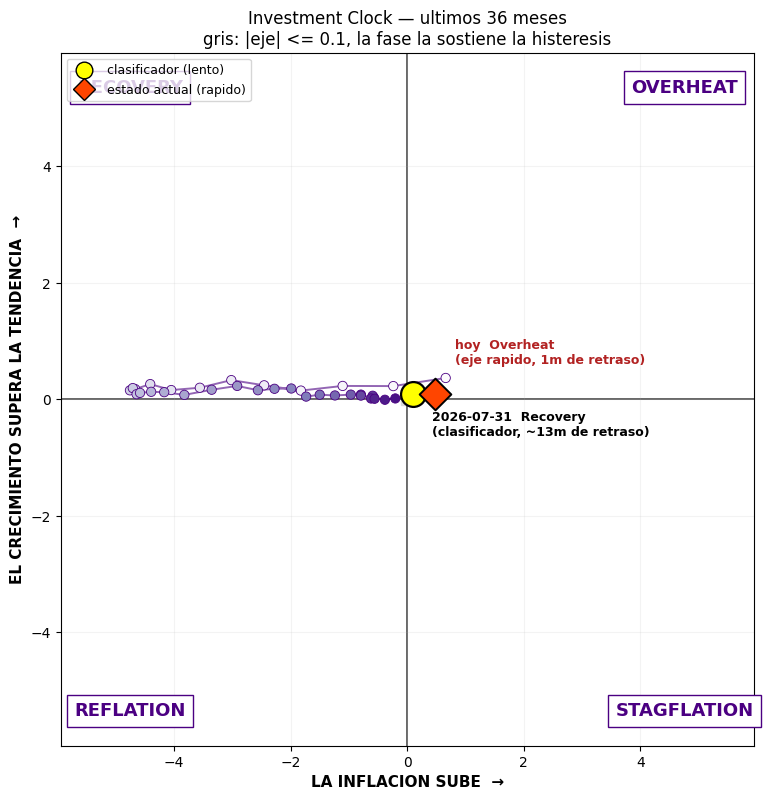

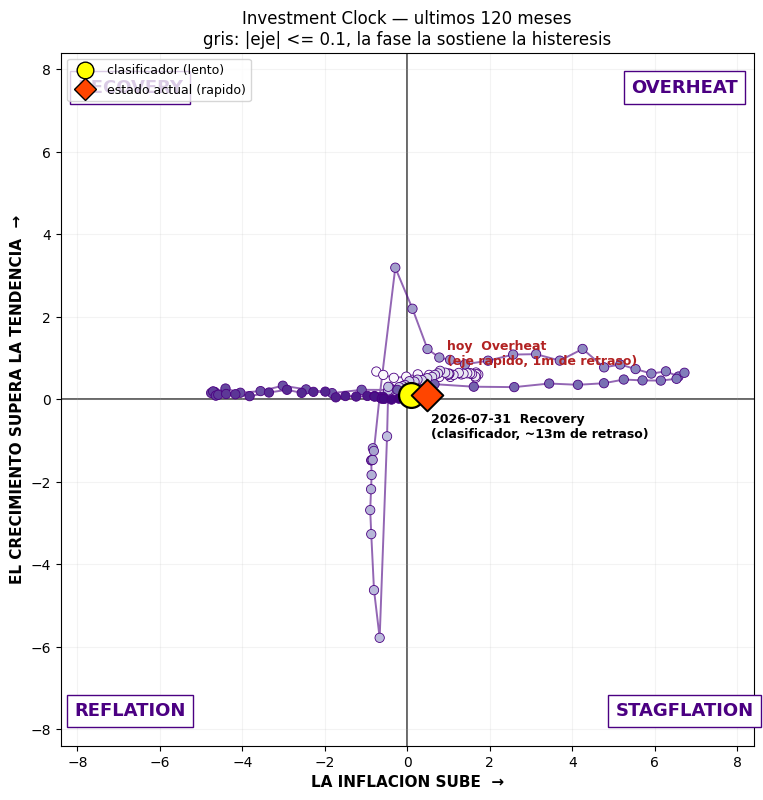

  [trial] 3/3.1-3.5: Reloj v2, mapeo estimado y gate (1 configs)

BLOQUE 3 COMPLETO.


In [ ]:
# ============================================================
# BLOQUE 3 — PASO 3.7 — Mapa del reloj
# ============================================================
# Dos cosas que el grafico de RLAM no muestra y este si:
#  - la ZONA GRIS del centro, donde la etiqueta la sostiene la histeresis y no el
#    dato. En su version el punto se ve igual de contundente este donde este.
#  - el punto del EJE RAPIDO. La distancia entre los dos puntos ES la transicion.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def mapa_reloj(clock, meses=36, banda=BANDA, guardar=None):
    d = clock.tail(meses)
    lim = max(d.crecimiento.abs().max(), d.inflacion.abs().max(),
              abs(d.inflacion_rapida.iloc[-1])) * 1.25

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.add_patch(plt.Rectangle((-banda, -banda), 2*banda, 2*banda,
                               color='0.85', zorder=0))
    ax.axhline(0, color='0.3', lw=1.2, zorder=1)
    ax.axvline(0, color='0.3', lw=1.2, zorder=1)

    for x, y, txt in [(-1, 1, 'RECOVERY'), (1, 1, 'OVERHEAT'),
                      (-1, -1, 'REFLATION'), (1, -1, 'STAGFLATION')]:
        ax.text(x*lim*0.80, y*lim*0.90, txt, ha='center', va='center',
                fontsize=13, fontweight='bold', color='#4B0082',
                bbox=dict(boxstyle='square,pad=0.4', fc='white', ec='#4B0082'))

    ax.plot(d.inflacion, d.crecimiento, '-', color='#4B0082', lw=1.4, alpha=0.6, zorder=2)
    ax.scatter(d.inflacion, d.crecimiento, c=range(len(d)), cmap='Purples',
               s=45, edgecolors='#4B0082', linewidths=0.6, zorder=3)

    u = d.iloc[-1]
    ax.scatter([u.inflacion], [u.crecimiento], s=320, c='yellow',
               edgecolors='black', linewidths=1.6, zorder=5)
    ax.annotate(f'{d.index[-1].date()}  {u.fase}\n(clasificador, ~13m de retraso)',
                (u.inflacion, u.crecimiento), xytext=(14, -30),
                textcoords='offset points', fontsize=9, fontweight='bold')

    # eje rapido: donde estamos HOY
    ax.scatter([u.inflacion_rapida], [u.crecimiento], s=260, marker='D',
               c='#FF4500', edgecolors='black', linewidths=1.4, zorder=5)
    ax.annotate(f'hoy  {u.fase_rapida}\n(eje rapido, 1m de retraso)',
                (u.inflacion_rapida, u.crecimiento), xytext=(14, 22),
                textcoords='offset points', fontsize=9, fontweight='bold',
                color='#B22222')
    if u.transicion:
        ax.annotate('', xy=(u.inflacion_rapida, u.crecimiento),
                    xytext=(u.inflacion, u.crecimiento),
                    arrowprops=dict(arrowstyle='->', color='#B22222', lw=2, ls='--'))

    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('LA INFLACION SUBE  →', fontsize=11, fontweight='bold')
    ax.set_ylabel('EL CRECIMIENTO SUPERA LA TENDENCIA  →', fontsize=11, fontweight='bold')
    ax.set_title(f'Investment Clock — ultimos {meses} meses\n'
                 f'gris: |eje| <= {banda}, la fase la sostiene la histeresis',
                 fontsize=12)
    ax.legend(handles=[
        Line2D([], [], marker='o', ls='', mfc='yellow', mec='black', ms=12,
               label='clasificador (lento)'),
        Line2D([], [], marker='D', ls='', mfc='#FF4500', mec='black', ms=11,
               label='estado actual (rapido)')], loc='upper left', fontsize=9)
    ax.grid(alpha=0.15)
    if guardar:
        fig.savefig(guardar, dpi=150, bbox_inches='tight')
    plt.show()

mapa_reloj(clock, 36,  guardar=DIRS['figures'] / 'b3_mapa_reloj_36m.png')
mapa_reloj(clock, 120, guardar=DIRS['figures'] / 'b3_mapa_reloj_120m.png')

log_trial(3, '3.1-3.5', 'Reloj v2, mapeo estimado y gate', n_configs=1,
          parametros=f'crecimiento MA{VENT} causal; inflacion MA12/diff18; '
                     f'clasificacion por signo de ambos ejes',
          notas=f'Gate {n_ok}/4. Mapeo estimado: {mapeo}. '
                f'Coincidencias con Greetham: {coincidencias}/4 (referencia, no criterio: '
                f'el mapeo del paper puede ser propio de 1973-2004). '
                f'Persistencia {dur.mean():.1f}m en {len(dur)} episodios.')

print('\nBLOQUE 3 COMPLETO.')


In [ ]:
import glob, json, re

nbs = glob.glob('/content/drive/MyDrive/TFM_regime_allocation/rdp_downloader.py',
                recursive=True)
print(f'{len(nbs)} notebooks')

for p in nbs:
    try:
        txt = open(p, encoding='utf-8').read()
    except Exception:
        continue
    if 'def a_mensual' in txt:
        print('\n>>>', p)
        nb = json.loads(txt)
        for c in nb.get('cells', []):
            src = ''.join(c.get('source', []))
            if 'def a_mensual' in src:
                i = src.index('def a_mensual')
                print(src[i:i+400])
                print('-' * 40)

1 notebooks
